# LIME and SHAP Tutorial on a Logistic Regression: Explaining Diabetes-Risk Predictions

**Dataset:** BRFSS 2015 diabetes health indicators (50/50 split) — predict `Diabetes_binary` from 21 health-indicator features.

**Outline:**
1. Load & explore the data
2. Pre-process (same split and scaling as `Log_Reg.ipynb`)
3. Train the logistic regression
4. Build the LIME explainer
5. Explain a single prediction with LIME
6. LIME: no-diabetes prediction for contrast
7. LIME: stability across random seeds
8. LIME: aggregate weights for a pseudo-global view
9. SHAP: single-instance and global explanations
10. LIME vs SHAP — side-by-side comparison

## 0. Install dependencies

In [21]:
%pip install lime shap torch scikit-learn pandas numpy matplotlib scipy --quiet

Note: you may need to restart the kernel to use updated packages.


## 1. Load the data

X: (70692, 21), y: (70692,)
Classes: [35346 35346]
Train: 45242, Val: 11311, Test: 14139
Train mean: [ 0. -0. -0.  0. -0.  0. -0.  0.  0. -0.  0.  0. -0. -0. -0.  0.  0. -0.
  0.  0.  0.]
Train std:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Early stopping at epoch 8
Best epoch: 3, val loss: 0.5102
Train accuracy: 0.746
Val accuracy:   0.754
Test accuracy:  0.750
Test accuracy: 0.750
ROC-AUC:       0.829

              precision    recall  f1-score   support

 No diabetes      0.758     0.734     0.746      7069
    Diabetes      0.742     0.765     0.754      7070

    accuracy                          0.750     14139
   macro avg      0.750     0.750     0.750     14139
weighted avg      0.750     0.750     0.750     14139



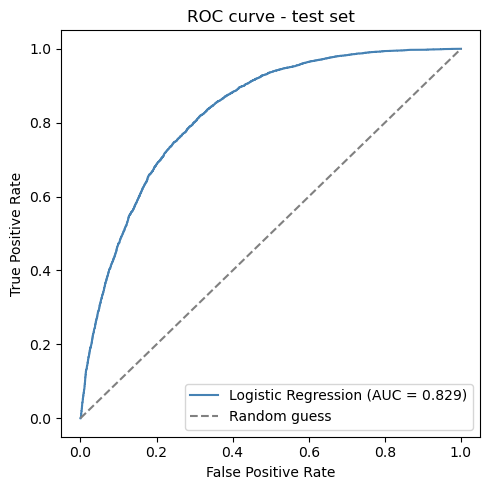

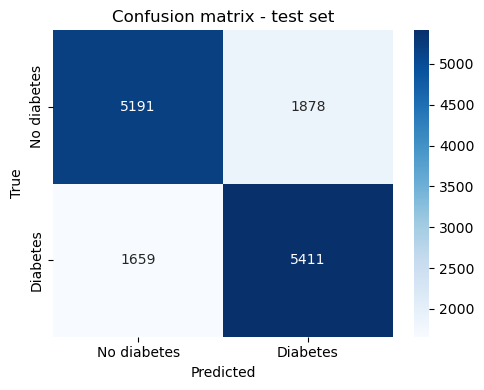

              precision    recall  f1-score   support

 No diabetes       0.76      0.73      0.75      7069
    Diabetes       0.74      0.77      0.75      7070

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139

Train loss: 0.5138
Val loss:   0.5102
Test loss:  0.5089


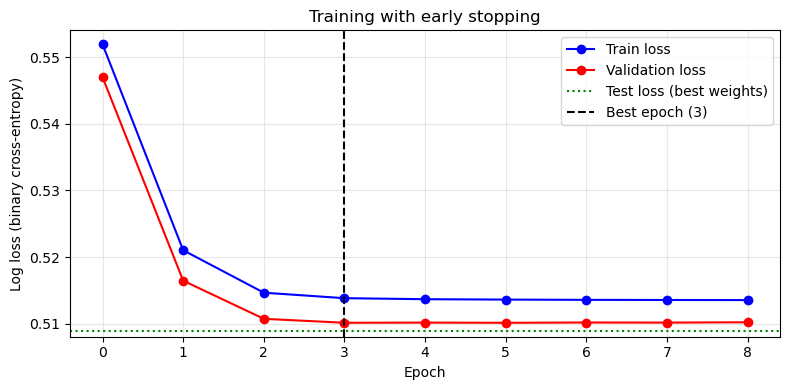

In [22]:
%run Log_Reg.ipynb

In [23]:
TARGET = 'Diabetes_binary'
FEATURE_COLS = feature_names
class_names = ['No diabetes', 'Diabetes']
pos_label = 1          # index of the 'Diabetes' class
SEED = seed

# Binary (0/1) features are treated as categorical by LIME; ordinal features (Age, GenHlth, ...) stay numeric
cat_cols = [c for c in FEATURE_COLS
            if set(np.unique(X_train_raw[:, FEATURE_COLS.index(c)])) <= {0, 1}]
num_cols = [c for c in FEATURE_COLS if c not in cat_cols]
cat_indices = [FEATURE_COLS.index(c) for c in cat_cols]

# Readable names for LIME plots (0 = No, 1 = Yes; for Sex: 0 = female, 1 = male)
categorical_names = {FEATURE_COLS.index(c): (['Female', 'Male'] if c == 'Sex' else ['No', 'Yes'])
                     for c in cat_cols}

print('Categorical (binary):', cat_cols)
print('Numerical / ordinal :', num_cols)

Categorical (binary): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Numerical / ordinal : ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


In [24]:
# Prediction functions on UNSCALED data (standardization is applied inside)
def predict_proba(X_raw_array):
    X_scaled = (np.asarray(X_raw_array, dtype=float) - train_mean) / train_std
    return model.predict_proba(X_scaled)

def predict(X_raw_array):
    return (predict_proba(X_raw_array)[:, 1] >= 0.5).astype(int)

# Sanity check: must give the same predictions as the model on the scaled test set
assert np.allclose(predict_proba(X_test_raw), model.predict_proba(X_test))
test_pred = predict(X_test_raw)
print(f'Test accuracy: {np.mean(test_pred == y_test):.3f}')

Test accuracy: 0.750


In [25]:
import shap

# SHAP for logistic regression: LinearExplainer (exact, deterministic, fast)
N_BACKGROUND = 200
rng_bg = np.random.default_rng(SEED)
bg_idx = rng_bg.choice(len(X_train), size=N_BACKGROUND, replace=False)
background = X_train[bg_idx]      # scaled data, like the model was trained on

lin_explainer = shap.LinearExplainer(
    model, shap.maskers.Independent(background, max_samples=N_BACKGROUND)
)

N_SHAP = 500
sv_pos_all = lin_explainer.shap_values(X_test[:N_SHAP])          # (N_SHAP, n_features)
expected_val = float(np.ravel(lin_explainer.expected_value)[0])

# Efficiency check: baseline + sum of SHAP values = log-odds (decision_function), NOT probability
reconstructed = expected_val + sv_pos_all.sum(axis=1)
print(f'SHAP values shape : {sv_pos_all.shape}')
print(f'Baseline (log-odds): {expected_val:.4f}')
print(f'Max |f(x) − (E[f(X)] + Σ SHAP)|: {np.max(np.abs(model.decision_function(X_test[:N_SHAP]) - reconstructed)):.2e}')

SHAP values shape : (500, 21)
Baseline (log-odds): 0.0504
Max |f(x) − (E[f(X)] + Σ SHAP)|: 8.88e-16


## 4. Build the LIME Explainer

`LimeTabularExplainer` needs:
- `training_data` — to learn the feature distributions for sampling (here: the **unscaled** training data)
- `feature_names` — column names
- `class_names` — label names
- `categorical_features` — indices of the binary columns
- `categorical_names` — mapping from encoded integer → readable string (for display)

In [26]:
import lime
import lime.lime_tabular

# Readable names for the binary features (0 = No, 1 = Yes; for Sex: 0 = female, 1 = male)
categorical_names = {}
for col in cat_cols:
    col_idx = FEATURE_COLS.index(col)
    categorical_names[col_idx] = ['Female', 'Male'] if col == 'Sex' else ['No', 'Yes']

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_raw,
    feature_names=FEATURE_COLS,
    class_names=class_names,
    categorical_features=cat_indices,
    categorical_names=categorical_names,
    mode='classification',
    random_state=42,
)
print('Explainer ready.')

Explainer ready.


## 5. Explain a single prediction

Pick one test instance and see *why* the network made its prediction.

In [27]:
# Pick the first test instance predicted as Diabetes
diabetes_mask = test_pred == pos_label
idx = np.where(diabetes_mask)[0][0]

instance = X_test_raw[idx]
pred_proba = predict_proba(instance.reshape(1, -1))[0]
pred_class = class_names[int(pred_proba.argmax())]

print(f'Explaining instance index {idx}')
print(f'Predicted class : {pred_class}   (true class: {class_names[int(y_test[idx])]})')
print(f'Class probabilities: {dict(zip(class_names, pred_proba.round(3)))}')
pd.Series(instance, index=FEATURE_COLS).to_frame('value').T

Explaining instance index 1
Predicted class : Diabetes   (true class: Diabetes)
Class probabilities: {'No diabetes': np.float64(0.435), 'Diabetes': np.float64(0.565)}


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
value,1.0,1.0,1.0,35.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,0.0,5.0,5.0,8.0


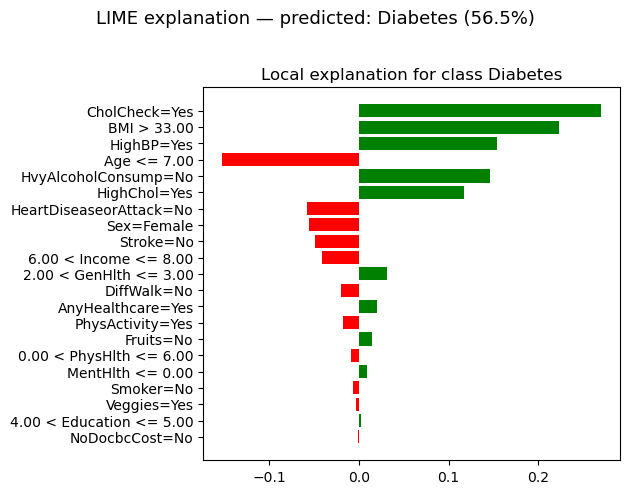

In [28]:
exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=predict_proba,
    num_features=21,      # top-10 features in the explanation
    num_samples=5000,     # neighbourhood samples for the surrogate
)

fig = exp.as_pyplot_figure(label=pos_label)
fig.suptitle(f'LIME explanation — predicted: {pred_class} ({pred_proba.max():.1%})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Reading the plot

- **Green bars** push the prediction *toward* `Diabetes`; **red bars** push it *away*.
- Each bar is labelled with the feature condition for *this specific instance* (e.g. `HighBP=Yes`, `BMI > 33.00`).
- The x-axis is the weight of that feature in the local linear surrogate — not a global feature importance.

In [29]:
# Also inspect the raw weights as a DataFrame
weights = exp.as_list(label=pos_label)
pd.DataFrame(weights, columns=['feature condition', 'LIME weight']).sort_values(
    'LIME weight', key=abs, ascending=False
)

,feature condition,LIME weight
0,CholCheck=Yes,0.270234
1,BMI > 33.00,0.223521
2,HighBP=Yes,0.154065
3,Age <= 7.00,-0.152487
4,HvyAlcoholConsump=No,0.146177
5,HighChol=Yes,0.116991
6,HeartDiseaseorAttack=No,-0.057544
7,Sex=Female,-0.055772
8,Stroke=No,-0.049515
9,6.00 < Income <= 8.00,-0.040964


## 6. Explain a no-diabetes prediction for contrast

Explaining instance index 0 (true class: No diabetes)


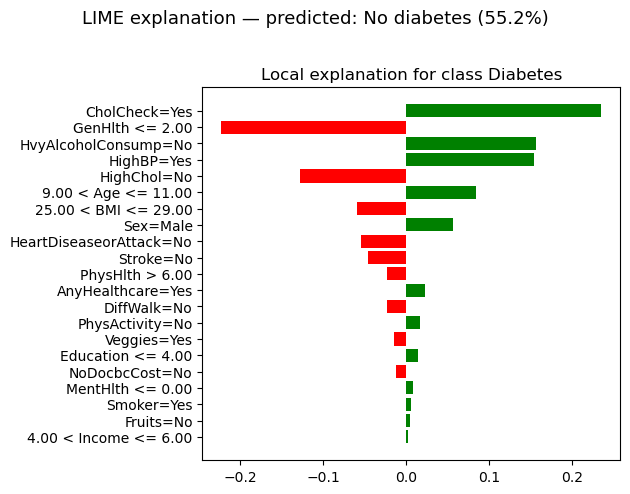

In [30]:
no_diabetes_mask = test_pred == 0
idx2 = np.where(no_diabetes_mask)[0][0]

instance2 = X_test_raw[idx2]
pred_proba2 = predict_proba(instance2.reshape(1, -1))[0]
pred_class2 = class_names[int(pred_proba2.argmax())]

exp2 = explainer.explain_instance(
    data_row=instance2,
    predict_fn=predict_proba,
    num_features=21,
    num_samples=5000,
)

print(f'Explaining instance index {idx2} (true class: {class_names[int(y_test[idx2])]})')
fig2 = exp2.as_pyplot_figure(label=pos_label)
fig2.suptitle(f'LIME explanation — predicted: {pred_class2} ({pred_proba2.max():.1%})',
              fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Stability: same instance, different random seeds

LIME is stochastic — the neighbourhood is sampled randomly.
Let's check how stable the top features are across seeds.

In [31]:
from collections import Counter

N_RUNS = 10
top_k = 5

feature_counts = Counter()
for seed in range(N_RUNS):
    local_exp = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_raw,
        feature_names=FEATURE_COLS,
        class_names=class_names,
        categorical_features=cat_indices,
        categorical_names=categorical_names,
        mode='classification',
        random_state=seed,
    ).explain_instance(
        data_row=instance,
        predict_fn=predict_proba,
        num_features=top_k,
        num_samples=5000,
    )
    for feat_name, _ in local_exp.as_list(label=pos_label):
        feature_counts[feat_name] += 1

stability_df = pd.DataFrame(
    feature_counts.most_common(), columns=['feature condition', f'appearances (/{N_RUNS})']
)
print(stability_df.to_string(index=False))

feature condition  appearances (/10)
    CholCheck=Yes                 10
      BMI > 33.00                 10
      Age <= 7.00                 10
       HighBP=Yes                 10
     HighChol=Yes                 10


Features appearing in all 10 runs are the most reliable parts of the explanation.
If a feature only appears in 2–3 runs, treat it with caution.

## 8. Aggregate LIME weights over many test instances

LIME is designed for *local* explanations, but averaging weights over many instances gives a rough global picture of which features matter most.

Note: we map weights to features with `exp.as_map()`, which returns `(feature index, weight)` pairs. Matching on the condition string would miss conditions that start with a number, such as `24.00 < BMI <= 27.00`.

In [32]:
N_EXPLAIN = 100  # increase for smoother averages (slower)
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(X_test_raw), size=N_EXPLAIN, replace=False)

weight_accumulator = {f: [] for f in FEATURE_COLS}

for i in sample_idx:
    e = explainer.explain_instance(
        data_row=X_test_raw[i],
        predict_fn=predict_proba,
        num_features=len(FEATURE_COLS),
        num_samples=1000,   # fewer samples → faster but noisier
    )
    for feat_idx, w in e.as_map()[pos_label]:
        weight_accumulator[FEATURE_COLS[feat_idx]].append(w)

mean_abs_weight = {
    f: np.mean(np.abs(ws)) for f, ws in weight_accumulator.items() if ws
}
global_df = pd.DataFrame(
    sorted(mean_abs_weight.items(), key=lambda x: x[1], reverse=True),
    columns=['feature', 'mean |LIME weight|']
)
print(global_df.to_string(index=False))

             feature  mean |LIME weight|
           CholCheck            0.235220
             GenHlth            0.163513
              HighBP            0.150658
   HvyAlcoholConsump            0.148270
            HighChol            0.121665
                 BMI            0.113906
                 Age            0.094402
                 Sex            0.054913
HeartDiseaseorAttack            0.053877
              Stroke            0.036157
              Income            0.031511
            DiffWalk            0.022464
       AnyHealthcare            0.021828
            MentHlth            0.015290
             Veggies            0.013858
            PhysHlth            0.013710
        PhysActivity            0.013329
           Education            0.013242
         NoDocbcCost            0.011366
              Fruits            0.008300
              Smoker            0.007203


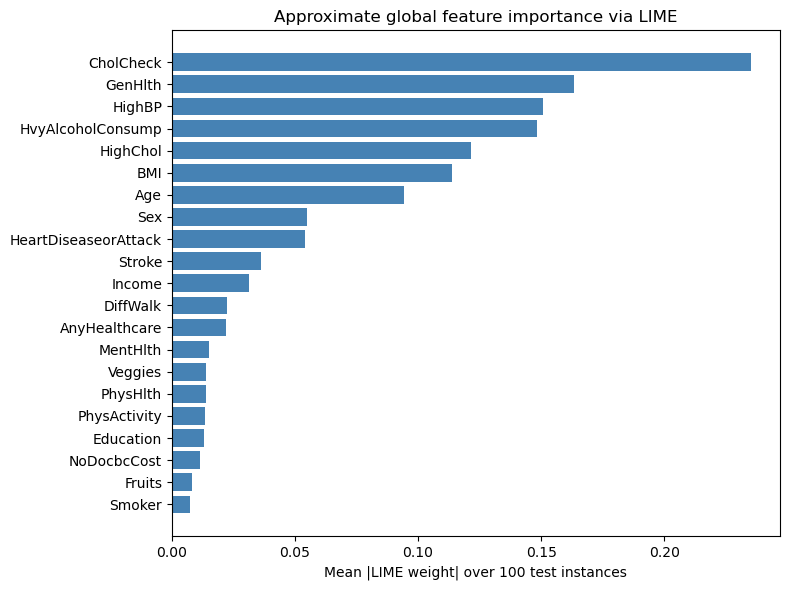

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(global_df['feature'][::-1], global_df['mean |LIME weight|'][::-1], color='steelblue')
ax.set_xlabel(f'Mean |LIME weight| over {N_EXPLAIN} test instances')
ax.set_title('Approximate global feature importance via LIME')
plt.tight_layout()
plt.show()

## 9. SHAP: interpreting the same model differently

**SHAP** (SHapley Additive exPlanations) computes each feature's contribution using Shapley values from cooperative game theory.

For a logistic regression we use **`shap.LinearExplainer`** (set up in section 2):
- For a linear model, the SHAP value of feature j is simply `coef_j * (x_j − E[x_j])` in the scaled space, so the values are **exact** and no approximation is needed.
- It works on the **log-odds** (the output of `decision_function`), not the probability. The SHAP values are therefore on a different scale than the LIME weights, which explain `P(Diabetes)`.

**Key properties:**
- **Efficiency** — SHAP values sum to `f(x) − E[f(background)]`: the gap between the log-odds of the prediction and the average log-odds on the background data.
- **Deterministic** — for a fixed background sample there is no sampling noise. A different background only shifts `E[x_j]` slightly.
- **Exact** — unlike DeepSHAP for the neural network, these are the true Shapley values for this model (assuming independent features).


### 9.1 Single-instance explanations with SHAP

A **waterfall plot** starts from the baseline `E[f(X)]` and stacks each feature's contribution until it reaches the model's prediction `f(x)`.

- **Red bars** push the prediction *higher* (toward `Diabetes`).
- **Blue bars** push it *lower*.
- The bars sum to `f(x) − E[f(X)]`.

The values shown next to the feature names are the original (unscaled) feature values.
Compare these with the LIME bar charts in sections 5–6 — same instance, same model, different method.

Instance predicted as: Diabetes (56.5%)


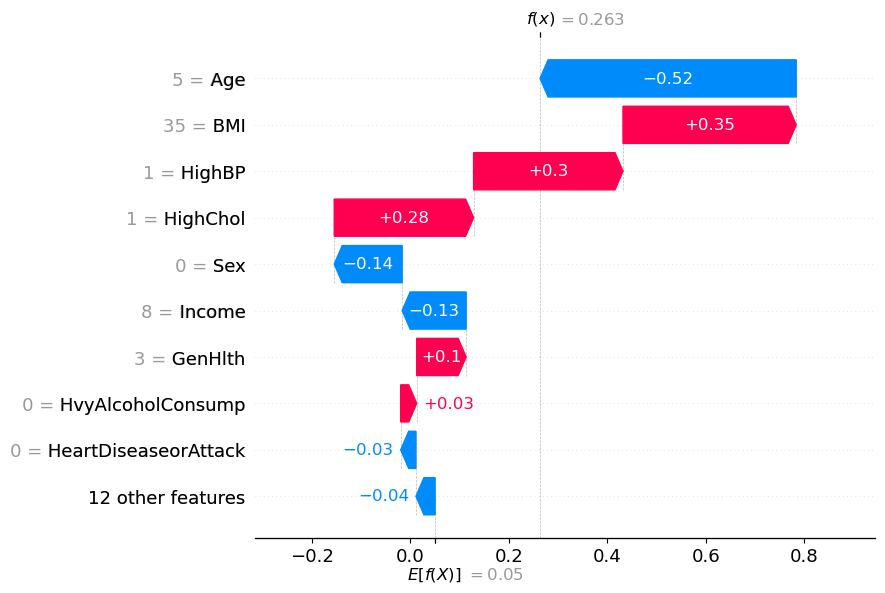

In [34]:
sv_hi_pos = lin_explainer.shap_values(X_test[idx:idx + 1])[0]        # log-odds contributions

shap_exp_hi = shap.Explanation(
    values=sv_hi_pos,
    base_values=expected_val,
    data=instance,              # unscaled values for display
    feature_names=FEATURE_COLS,
)
print(f'Instance predicted as: {pred_class} ({pred_proba.max():.1%})')
shap.plots.waterfall(shap_exp_hi)

Instance predicted as: No diabetes (55.2%)


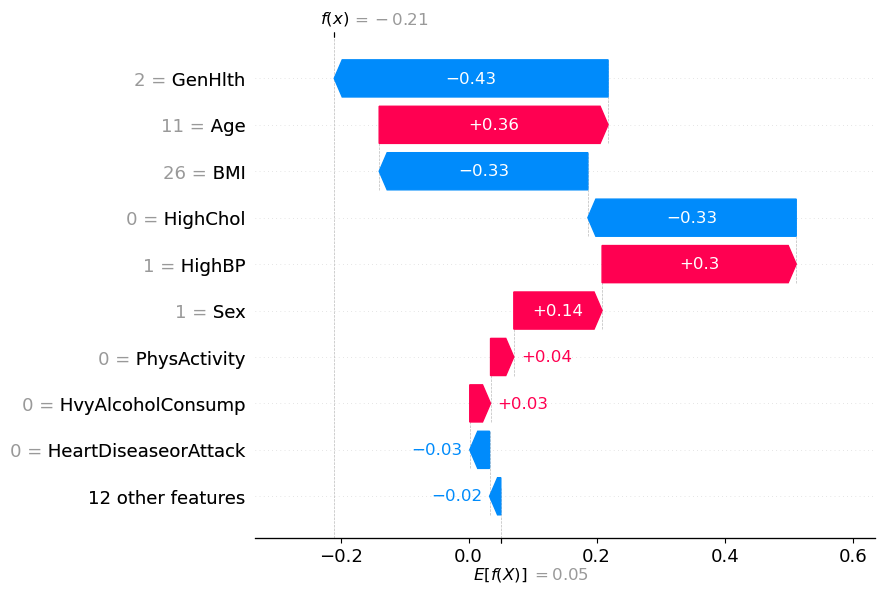

In [35]:
sv_lo_pos = lin_explainer.shap_values(X_test[idx2:idx2 + 1])[0]

shap_exp_lo = shap.Explanation(
    values=sv_lo_pos,
    base_values=expected_val,
    data=instance2,
    feature_names=FEATURE_COLS,
)
print(f'Instance predicted as: {pred_class2} ({pred_proba2.max():.1%})')
shap.plots.waterfall(shap_exp_lo)

### 9.2 Global feature importance: the SHAP summary plot

Aggregating SHAP values over many instances gives a consistent global picture.

A **beeswarm plot** shows every instance as a dot. The x-axis is the SHAP value; colour encodes the raw feature value (red = high, blue = low). This reveals not just *which* features matter, but *how* their values relate to predictions — something a simple bar chart can't show.

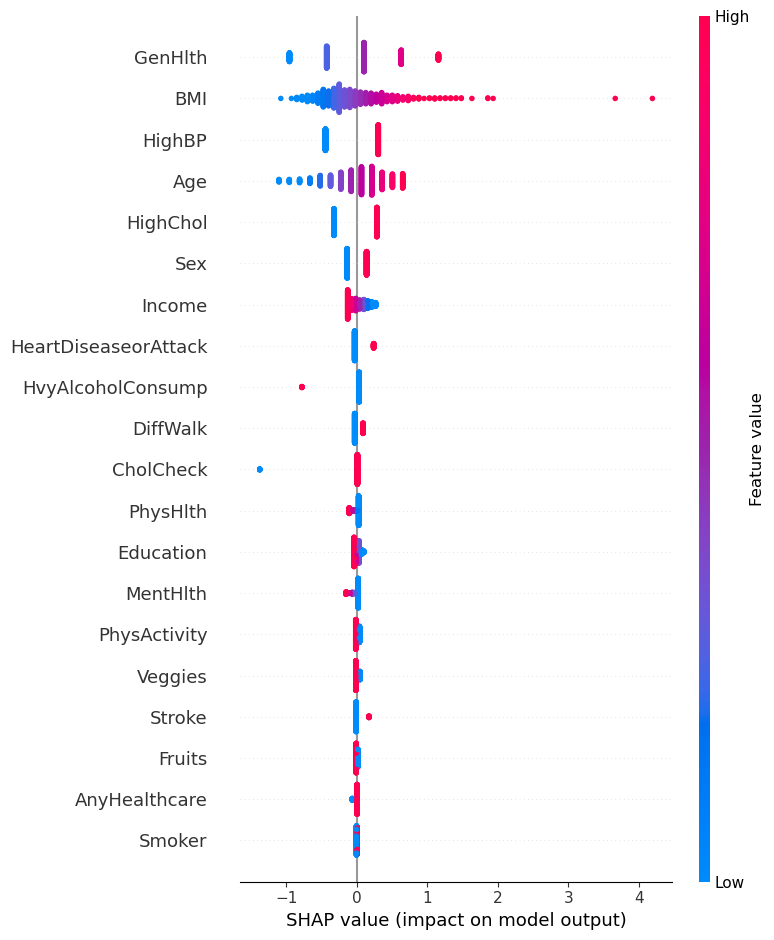

In [36]:
shap.summary_plot(sv_pos_all, X_test_raw[:N_SHAP], feature_names=FEATURE_COLS)

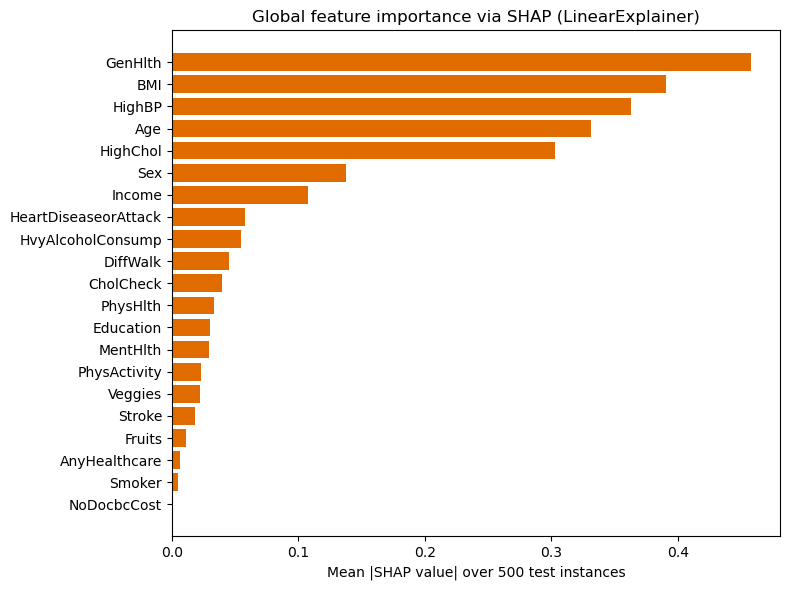

             feature  mean |SHAP|
             GenHlth     0.457769
                 BMI     0.390674
              HighBP     0.363261
                 Age     0.331388
            HighChol     0.303140
                 Sex     0.137872
              Income     0.107377
HeartDiseaseorAttack     0.057885
   HvyAlcoholConsump     0.054921
            DiffWalk     0.045210
           CholCheck     0.039805
            PhysHlth     0.033188
           Education     0.030261
            MentHlth     0.029372
        PhysActivity     0.023169
             Veggies     0.021991
              Stroke     0.018302
              Fruits     0.011268
       AnyHealthcare     0.006109
              Smoker     0.004842
         NoDocbcCost     0.000408


In [37]:
mean_abs_shap = np.mean(np.abs(sv_pos_all), axis=0)
shap_global_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'mean |SHAP|': mean_abs_shap,
}).sort_values('mean |SHAP|', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(shap_global_df['feature'][::-1], shap_global_df['mean |SHAP|'][::-1], color='#e06c00')
ax.set_xlabel(f'Mean |SHAP value| over {N_SHAP} test instances')
ax.set_title('Global feature importance via SHAP (LinearExplainer)')
plt.tight_layout()
plt.show()
print(shap_global_df.to_string(index=False))

## 10. LIME vs SHAP — side-by-side comparison

Both methods attribute a prediction to its features, but via different mechanisms. Here we compare them directly on **the same instance** and on the **same global ranking**.

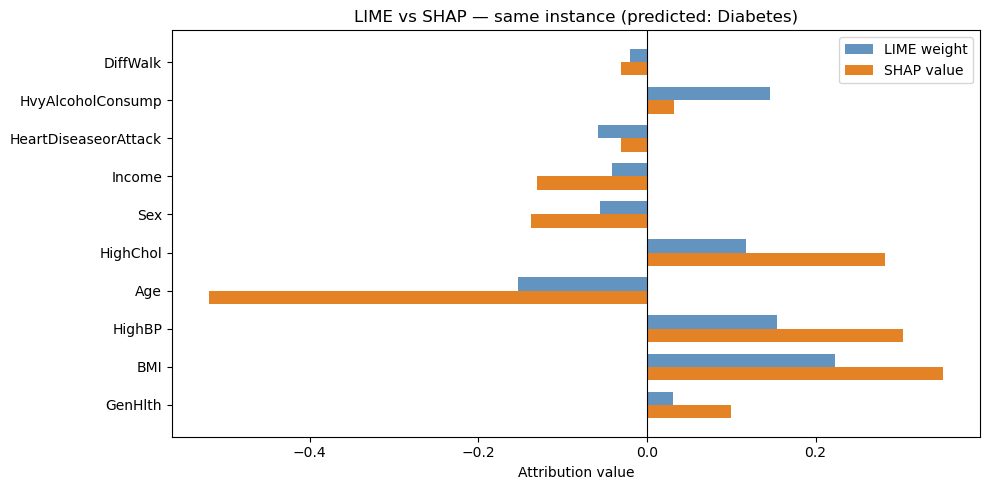

In [38]:
# LIME weights for the diabetes instance → map to feature names
lime_by_feature = {FEATURE_COLS[i]: w for i, w in exp.as_map()[pos_label]}

# SHAP values for the same instance
shap_by_feature = dict(zip(FEATURE_COLS, sv_hi_pos))

# Compare over the top-10 features by mean |SHAP| (global ranking)
top10 = shap_global_df['feature'].head(10).tolist()
lime_local = [lime_by_feature.get(f, 0) for f in top10]
shap_local = [shap_by_feature[f] for f in top10]

x = np.arange(len(top10))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(x + bar_w/2, lime_local, bar_w, label='LIME weight', color='steelblue', alpha=0.85)
ax.barh(x - bar_w/2, shap_local, bar_w, label='SHAP value', color='#e06c00', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(top10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Attribution value')
ax.set_title(f'LIME vs SHAP — same instance (predicted: {pred_class})')
ax.legend()
plt.tight_layout()
plt.show()

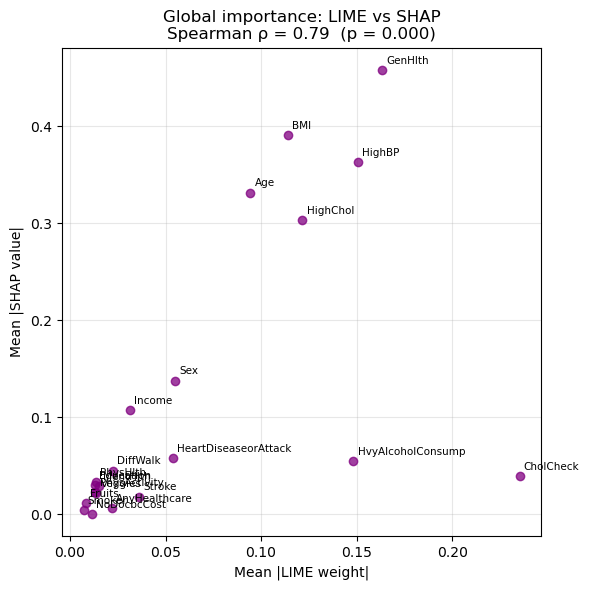

Spearman rank correlation: ρ = 0.795,  p = 0.0000


In [39]:
from scipy.stats import spearmanr

# Align global rankings by feature name
lime_series = global_df.set_index('feature')['mean |LIME weight|']
shap_series = shap_global_df.set_index('feature')['mean |SHAP|']
aligned = pd.DataFrame({'LIME': lime_series, 'SHAP': shap_series}).dropna()

rho, pval = spearmanr(aligned['LIME'], aligned['SHAP'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(aligned['LIME'], aligned['SHAP'], color='purple', alpha=0.75, zorder=3)
for feat, row in aligned.iterrows():
    ax.annotate(feat, (row['LIME'], row['SHAP']), fontsize=7.5, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Mean |LIME weight|')
ax.set_ylabel('Mean |SHAP value|')
ax.set_title(f'Global importance: LIME vs SHAP\nSpearman ρ = {rho:.2f}  (p = {pval:.3f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Spearman rank correlation: ρ = {rho:.3f},  p = {pval:.4f}')